# C2 — v1 vs. v2 vs. the dilated bottleneck: one architecture family, three checkpoints

Each architecture family is loaded **three** times and scored side by side on the same `data/test/` images, with the same signals, tables and figures the 04x/05x series uses:

| column | checkpoint | what it is |
|---|---|---|
| `v1` | `models/v1/<arch>/` | the pre-`fixing.md` run |
| `v2` | `models/deterministic/<arch>/` | the same architecture after Rounds 1-2 |
| `v2 dilated` | `models/deterministic/<arch>_dilated/` | Round 3's dilated-bottleneck variant of it (`fixing.md` #7) |

So the two families compared here are `unet` → `unet` → `unet_dilated` and `unet_v2` → `unet_v2` → `unet_v2_dilated`. Every table prints the three columns followed by the **consecutive** deltas `Δ v2-v1` and `Δ v2 dilated-v2`, which separates the two questions the notebook answers: *what did the fixing rounds buy*, and *what does the dilated bottleneck add on top of them*.

**What changed between the two generations** (`fixing.md`, Rounds 1-2), i.e. what the first delta measures:

| | `v1` | `v2` (`deterministic/` + `nll/`) |
|---|---|---|
| normalization | `BatchNormalization` | `GroupNormalization` (`scripts/norm_utils.py`) |
| ReLU | `layers.ReLU()` | `_ReLUFix` (tensorflow-metal NaN workaround) |
| deterministic loss | per-architecture (`combined_loss` / `combined_loss_advanced`) | unified `combined_loss` (Charbonnier + 1-MS-SSIM) |
| NLL loss | `gaussian_nll` (`models/v1/<arch>_nll/`), `beta_nll` (`models/v1/nll_beta/`) | unified `laplace_nll` |
| 2nd NLL channel | Gaussian **log-variance** → `sigma = exp(0.5 * ch1)` | Laplace **log-scale** → `sigma = sqrt(2) * exp(ch1)` |
| optimizer | plain Adam | Adam + `weight_decay` + `clipvalue` |

**What changes in the third column** (Round 3, `fixing.md` #7): only the bottleneck. `scripts/aspp.py`'s `dilated_bottleneck` replaces the plain bottleneck convs with parallel dilated branches (`settings.DILATION_RATES`) concatenated and projected back to the same channel count; everything else — encoder, decoder, normalization, loss, optimizer, schedule — is the `v2` recipe. The `Δ v2 dilated-v2` column is therefore a clean read on the receptive-field question alone.

**Read the tables with these two caveats in mind.**

1. The NLL second channel means *different things* in the two generations (row 5 above), so §3 converts it per variant rather than applying one formula to all — the exact mistake `fixing.md` #10 documents. Everything derived from `sigma` (`\|z\|`, structural z, calibration) depends on that conversion being right. The comparisons configured below are all deterministic, so this only matters if an NLL family is added to `COMPARISONS`.
2. `nll` in §8 is a **negative log-likelihood under a different distribution** on each side of the `v1 → v2` step (Gaussian nats vs. Laplace nats) and is therefore not subtractable *across that step*; §8 blanks exactly those deltas and keeps the ones between variants that share a distribution. Coverage, `z_std`, Spearman(error, sigma), sharpness and dispersion treat `sigma` as a plain standard deviation and are comparable everywhere.

Companion notebooks: `040`/`041` (signals vs. ground-truth masks, current generation only), `052` (a user-chosen subset of current models against each other), `C0`/`C1` (the two-column ancestors of this notebook).

Make the project root importable so `scripts.*` resolves regardless of the notebook's working directory.

In [1]:
import sys
from pathlib import Path

project_root = Path().absolute()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

Imports and a GPU sanity check. Same building blocks as the 04x/05x series: `scripts.delta_analysis` for the delta/structural maps, `scripts.calibration` for the z-score signals and the sigma metrics, `scripts.detection` for AUROC against the hand-drawn masks, `scripts.stroke_stats` for the reference-free corroboration.

In [2]:
import gc
from typing import NamedTuple

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from PIL import Image

from scripts.calibration import (
    evaluate_calibration,
    laplace_sigma_from_scale,
    learned_zscore,
    structural_zscore,
)
from scripts.config import settings
from scripts.dataset import pad_to_multiple
from scripts.delta_analysis import analyze_delta
from scripts.detection import evaluate_detection
from scripts.stroke_stats import stroke_coherence
from scripts.trainer import load_model
from scripts.trainer_nll import load_model_nll
from scripts.visualization_nll import DEFAULT_Z_SCALE, plot_signal_comparison

gpus = tf.config.list_physical_devices("GPU")
print(f"GPUs available: {gpus}")

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. The `data/test/` images

Every `(rgb, ir)` pair under `data/test/`, discovered generically. The three with a hand-drawn mask in `data/test/annotations/*_Map.png` (`GT01`, `GT02`, `GT03`) additionally carry a detection ground truth — §6's AUROC is restricted to those, everything else (fidelity, coherence, calibration) needs no mask and runs on all of them.

In [3]:
TEST_RGB_DIR = project_root / "data" / "test" / "rgb"
TEST_IR_DIR = project_root / "data" / "test" / "ir"
ANNOTATIONS_DIR = project_root / "data" / "test" / "annotations"

rgb_paths = sorted(TEST_RGB_DIR.glob("*.jpg")) + sorted(TEST_RGB_DIR.glob("*.png"))
image_pairs = [
    (p, TEST_IR_DIR / p.name)
    for p in sorted(rgb_paths)
    if (TEST_IR_DIR / p.name).exists()
]
gt_stems = {
    p.name.removesuffix("_Map.png") for p in sorted(ANNOTATIONS_DIR.glob("*_Map.png"))
}
gt_stems &= {p.stem for p, _ in image_pairs}

print(f"data/test/ images: {len(image_pairs)} | {[p.stem for p, _ in image_pairs]}")
print(f"with a ground-truth mask: {sorted(gt_stems)}")

if not image_pairs:
    raise RuntimeError("No (rgb, ir) pairs found under data/test/.")

data/test/ images: 10 | ['GT01', 'GT02', 'GT03', 'bridge', 'case', 'face', 'green', 'modern', 'modern2', 'total']
with a ground-truth mask: ['GT01', 'GT02', 'GT03']


## 2. The generations, and the three-column comparisons built on them

`VERSIONS` says where each generation's checkpoints live and how to read its NLL second channel — the only two things that differ structurally between them. `v1` keeps deterministic and NLL checkpoints in one flat `models/v1/` directory; `v2` splits them into `models/deterministic/` and `models/nll/`.

A `Variant` is one **column**: a label, the architecture to load, and the generation to load it from. A `Comparison` is one **family**: a name, its family (`deterministic` or `nll`, which decides how the checkpoint is loaded and which signals exist), and its ordered variants. Because the architecture is per-variant rather than per-comparison, the third column can be a *different* architecture in the same generation — which is exactly what the dilated variants are.

Every comparison must use the **same variant labels**, since §5-§9 print all comparisons under one shared header; the cell raises if they diverge. Deltas are always between consecutive labels, so the order of `variants` is the order of the story.

To add a family, append a `Comparison`. To compare the NLL side instead, use `family="nll"` with the `_nll` architecture names (`unet_nll`, …); §8 then wakes up. Any comparison missing a checkpoint for even one variant is skipped with a message rather than raising.

**On the v1 NLL entries**: `models/v1/<arch>_nll/` holds the pre-Round-2 `gaussian_nll` checkpoints; the `beta_nll` siblings live under `models/v1/nll_beta/<arch>_nll/`. To compare against those instead, point `VERSIONS["v1"]["dir"]["nll"]` at `settings.MODELS_DIR / "v1" / "nll_beta"` and set `nll_loss` to `"beta_nll"` — the second channel is still a Gaussian log-variance, so `sigma_source` stays `"gaussian"`.

In [4]:
VERSIONS = {
    "v1": {
        "dir": {
            "deterministic": settings.MODELS_DIR / "v1",
            "nll": settings.MODELS_DIR / "v1",
        },
        # Pre-Round-2: the NLL head was trained as a Gaussian, so channel 1
        # is a log-variance and the NLL metric in §8 is in Gaussian nats.
        "nll_loss": "gaussian_nll",
        "sigma_source": "gaussian",
    },
    "v2": {
        "dir": {
            "deterministic": settings.MODELS_DIR / "deterministic",
            "nll": settings.MODELS_DIR / "nll",
        },
        # fixing.md #10: every NLL architecture is now a Laplace, so
        # channel 1 is a log-scale and sigma = b * sqrt(2).
        "nll_loss": "laplace_nll",
        "sigma_source": "laplace",
    },
}


class Variant(NamedTuple):
    """One column of a comparison: which checkpoint, from which generation."""

    label: str  # column header, shared across every comparison
    arch: str  # architecture name, i.e. the sub-directory to load from
    version: str  # key into VERSIONS: where it lives, how to read its sigma


class Comparison(NamedTuple):
    """One architecture family, scored across its variants."""

    name: str
    family: str  # "deterministic" or "nll" — decides loader and signals
    variants: tuple[Variant, ...]


COMPARISONS = [
    Comparison(
        "unet",
        "deterministic",
        (
            Variant("v1", "unet", "v1"),
            Variant("v2", "unet", "v2"),
            Variant("v2 dilated", "unet_dilated", "v2"),
        ),
    ),
    Comparison(
        "unet_v2",
        "deterministic",
        (
            Variant("v1", "unet_v2", "v1"),
            Variant("v2", "unet_v2", "v2"),
            Variant("v2 dilated", "unet_v2_dilated", "v2"),
        ),
    ),
]

LABELS = [v.label for v in COMPARISONS[0].variants]
if any([v.label for v in c.variants] != LABELS for c in COMPARISONS):
    raise ValueError(
        "Every comparison must use the same variant labels, in the same order — "
        "the tables in §5-§9 print all comparisons under one shared header."
    )

# Consecutive (before, after) pairs — each table's delta columns.
STEPS = list(zip(LABELS, LABELS[1:]))


def checkpoint_path(variant: Variant, family: str) -> Path:
    """Where one variant's checkpoint is expected to be."""
    return VERSIONS[variant.version]["dir"][family] / variant.arch / "best_model.keras"


def load_variant(variant: Variant, family: str) -> tf.keras.Model:
    """Load one column's checkpoint."""
    spec = VERSIONS[variant.version]
    model_dir = spec["dir"][family]
    if family == "deterministic":
        return load_model(variant.arch, model_dir=model_dir)
    return load_model_nll(
        variant.arch,
        model_dir=model_dir,
        loss_name=spec["nll_loss"],
        beta=settings.NLL_BETA,
    )


for comparison in COMPARISONS:
    columns = " vs. ".join(
        f"{v.label}={v.arch}@{v.version}" for v in comparison.variants
    )
    print(f"{comparison.name} ({comparison.family}): {columns}")

missing = [
    f"{c.name}/{v.label}"
    for c in COMPARISONS
    for v in c.variants
    if not checkpoint_path(v, c.family).exists()
]
print(f"\nMissing checkpoints (their comparison is skipped): {missing or 'none'}")

unet (deterministic): v1=unet@v1 vs. v2=unet@v2 vs. v2 dilated=unet_dilated@v2
unet_v2 (deterministic): v1=unet_v2@v1 vs. v2=unet_v2@v2 vs. v2 dilated=unet_v2_dilated@v2

Missing checkpoints (their comparison is skipped): none


## 3. Signals, per variant

Identical construction to `040`/`041`/`052` — **raw delta** `|real_IR - mu|`, **structural delta** `1 - local SSIM structure`, **confidence** (their normalized agreement) for every model; plus **`\|z\|`** and **structural z** for the NLL architectures, which need a `sigma`.

The one thing that is *not* identical across variants is that `sigma`. `sigma_from_channel` dispatches on `VERSIONS[variant.version]["sigma_source"]`: `exp(0.5 * ch1)` for v1's Gaussian log-variance, `laplace_sigma_from_scale(exp(ch1))` (i.e. `sqrt(2) * b`) for v2's Laplace log-scale. Applying either formula to both generations would make the z-signals and every calibration number below silently wrong — this is `fixing.md` #10's mistake, and the reason this dispatch exists rather than one shared line. It is dormant for the deterministic comparisons configured above and live the moment an NLL family is added.

In [5]:
MASK_THRESHOLD = 127  # midpoint threshold for the mask's anti-aliased edges

SIGNAL_KINDS = ("raw delta", "structural delta", "confidence")
NLL_SIGNAL_KINDS = ("|z| (raw/sigma)", "structural z")


def load_pair(rgb_path: Path, ir_path: Path) -> tuple[np.ndarray, np.ndarray]:
    """Load an ``(rgb, ir)`` pair as float arrays in ``[0, 1]``."""
    rgb = np.array(Image.open(rgb_path).convert("RGB")).astype(np.float32) / 255.0
    ir = np.array(Image.open(ir_path).convert("L")).astype(np.float32) / 255.0
    return rgb, ir


def load_mask(stem: str) -> np.ndarray:
    """Load a hand-drawn ground-truth mask as a boolean array."""
    mask_path = ANNOTATIONS_DIR / f"{stem}_Map.png"
    return np.array(Image.open(mask_path).convert("L")) > MASK_THRESHOLD


def sigma_from_channel(log_channel: np.ndarray, sigma_source: str) -> np.ndarray:
    """Turn an NLL head's second channel into a standard deviation."""
    if sigma_source == "gaussian":
        return np.exp(0.5 * log_channel)
    if sigma_source == "laplace":
        return laplace_sigma_from_scale(np.exp(log_channel))
    raise ValueError(f"Unknown sigma_source '{sigma_source}'.")


def fidelity(ir: np.ndarray, mu: np.ndarray) -> dict[str, float]:
    """MAE/SSIM/PSNR of a prediction against the real IR, as in 030."""
    real = tf.constant(ir[..., np.newaxis])
    pred = tf.constant(mu[..., np.newaxis])
    return {
        "mae": float(np.mean(np.abs(ir - mu))),
        "ssim": float(tf.image.ssim(real, pred, max_val=1.0)),
        "psnr": float(tf.image.psnr(real, pred, max_val=1.0)),
    }


def predict_signals(
    model: tf.keras.Model, family: str, version: str, rgb: np.ndarray, ir: np.ndarray
) -> tuple[dict[str, float], dict[str, np.ndarray], np.ndarray | None, np.ndarray]:
    """Predict one image and build every signal available to this family."""
    padded, _ = pad_to_multiple(tf.constant(rgb), multiple=settings.PATCH_MULTIPLE)
    h, w = ir.shape
    pred = model.predict(padded[tf.newaxis, ...], verbose=0)[0, :h, :w, :]

    mu = pred[..., 0]
    result = analyze_delta(ir, mu)
    signals = {
        "raw delta": result.raw_delta,
        "structural delta": result.structural_delta,
        "confidence": result.confidence_map,
    }

    sigma = None
    if family == "nll":
        sigma = sigma_from_channel(pred[..., 1], VERSIONS[version]["sigma_source"])
        signals["|z| (raw/sigma)"] = np.abs(learned_zscore(ir, mu, sigma))
        signals["structural z"] = structural_zscore(result.structural_delta, sigma)

    return fidelity(ir, mu), signals, sigma, mu

## 4. The sweep

One family at a time, all three of its variants held in memory together (so their signals are built from the exact same image arrays), every `data/test/` image scored, then all three released before moving to the next family. Checkpoints run ~370-560 MB each, so a family costs ~1.5 GB resident — fine for three, which is why the loop is per-family rather than loading everything up front.

`PLOT_IMAGES` and `PLOT_SIGNALS` control only the *figures*; the numeric tables in §5-§8 always cover every image and every signal. The defaults plot the three ground-truth images, where a visible difference can be checked against the mask — widen to `{p.stem for p, _ in image_pairs}` for the full qualitative sweep. The figures put the real IR and all three variants on one row, on a shared color scale, so the dilated column can be read against its own `v2` baseline rather than in isolation.

This is the long cell: `len(COMPARISONS) x len(image_pairs) x len(LABELS)` full-image predictions on images up to ~10 Mpx, plus the Gaussian-windowed SSIM decomposition for each — i.e. 50% more work than the two-column version.

2026-08-27 20:50:26.782006: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-08-27 20:50:26.782040: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-08-27 20:50:26.782048: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-08-27 20:50:26.782111: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-27 20:50:26.782144: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)



=== unet (deterministic) — v1 vs. v2 vs. v2 dilated ===


2026-08-27 20:50:29.679585: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


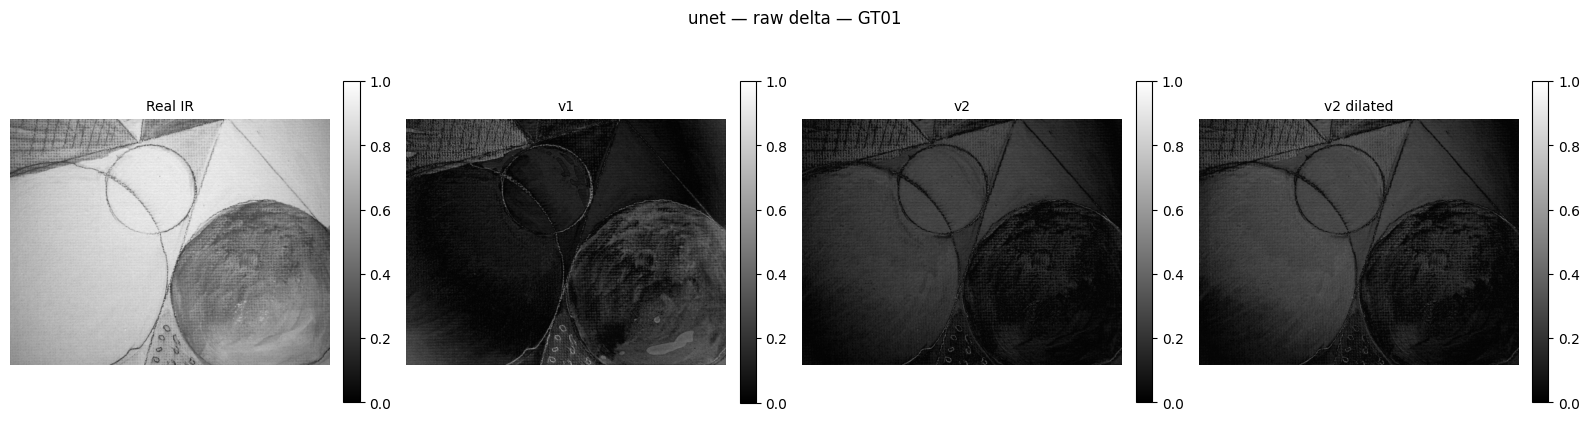

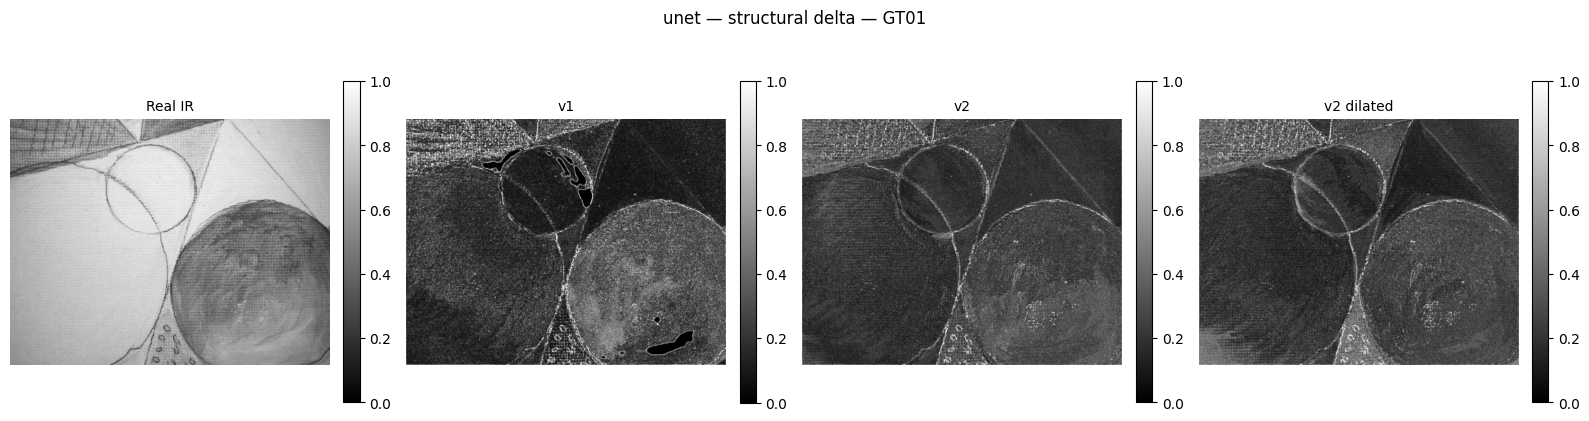

  GT01: scored


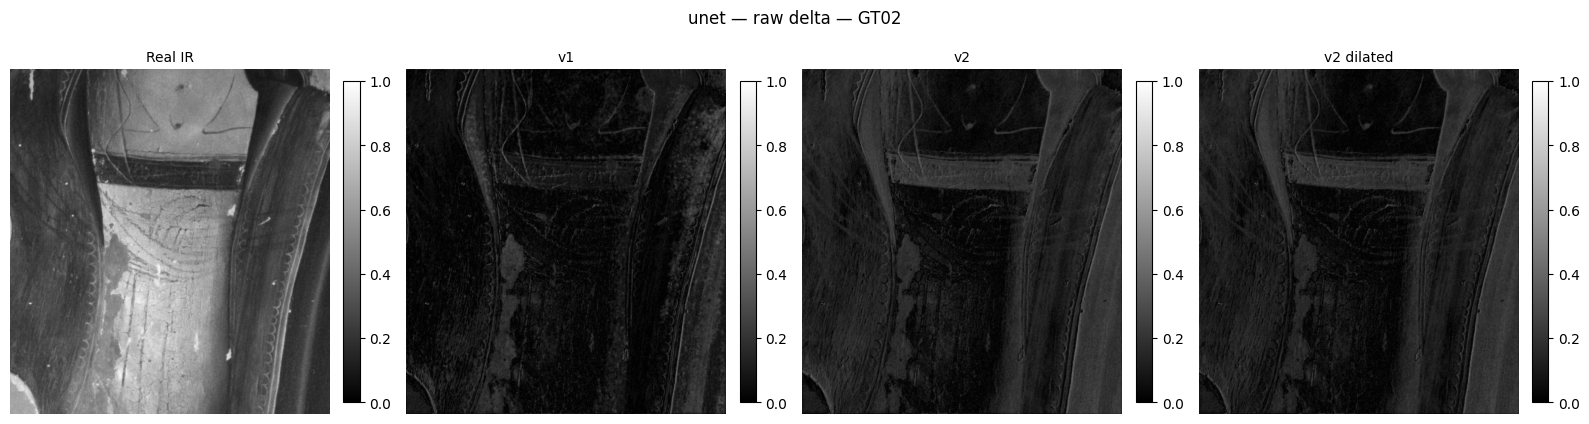

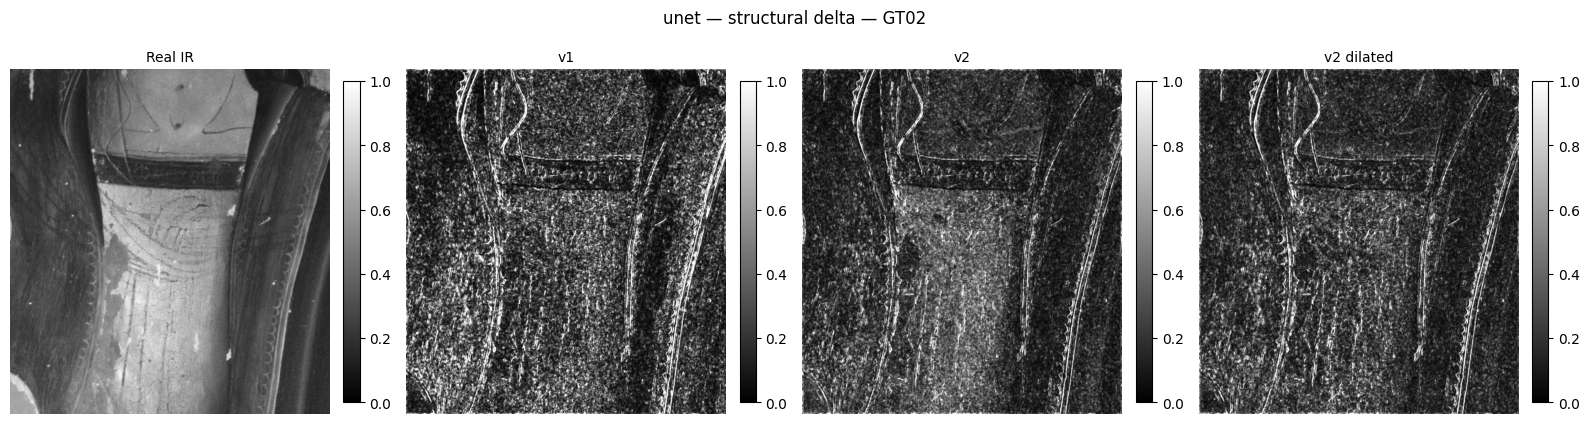

  GT02: scored


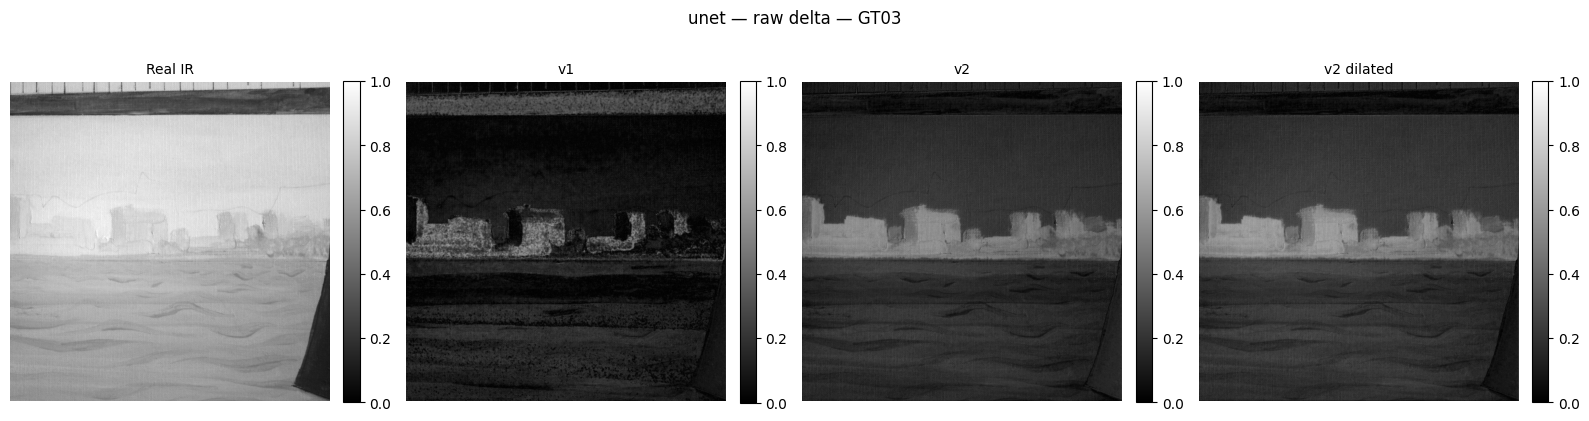

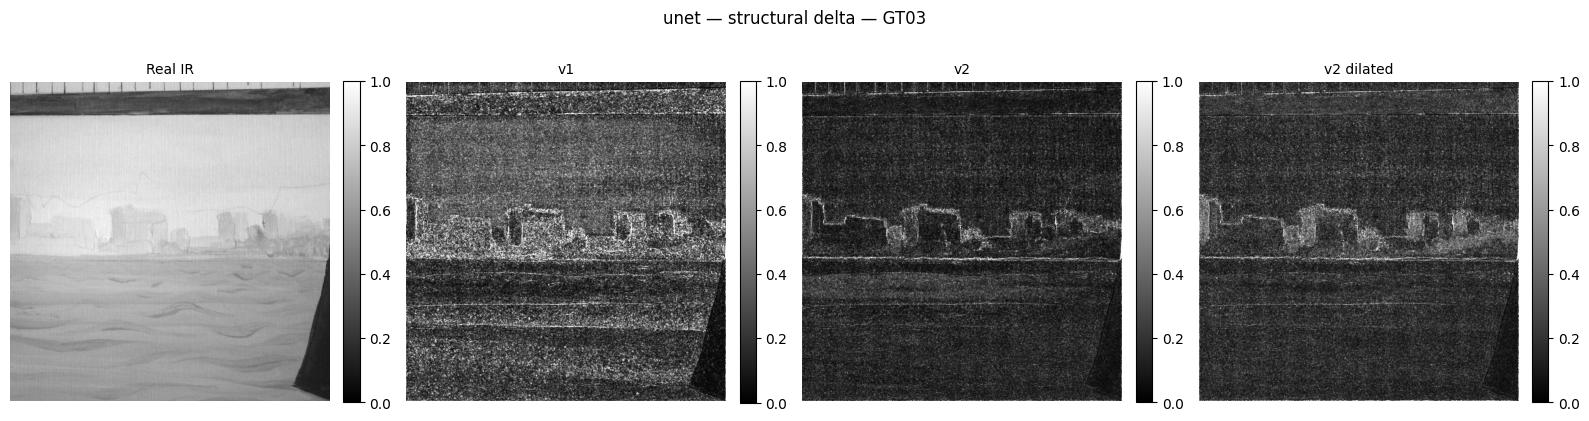

  GT03: scored
  bridge: scored
  case: scored
  face: scored
  green: scored
  modern: scored
  modern2: scored
  total: scored

=== unet_v2 (deterministic) — v1 vs. v2 vs. v2 dilated ===


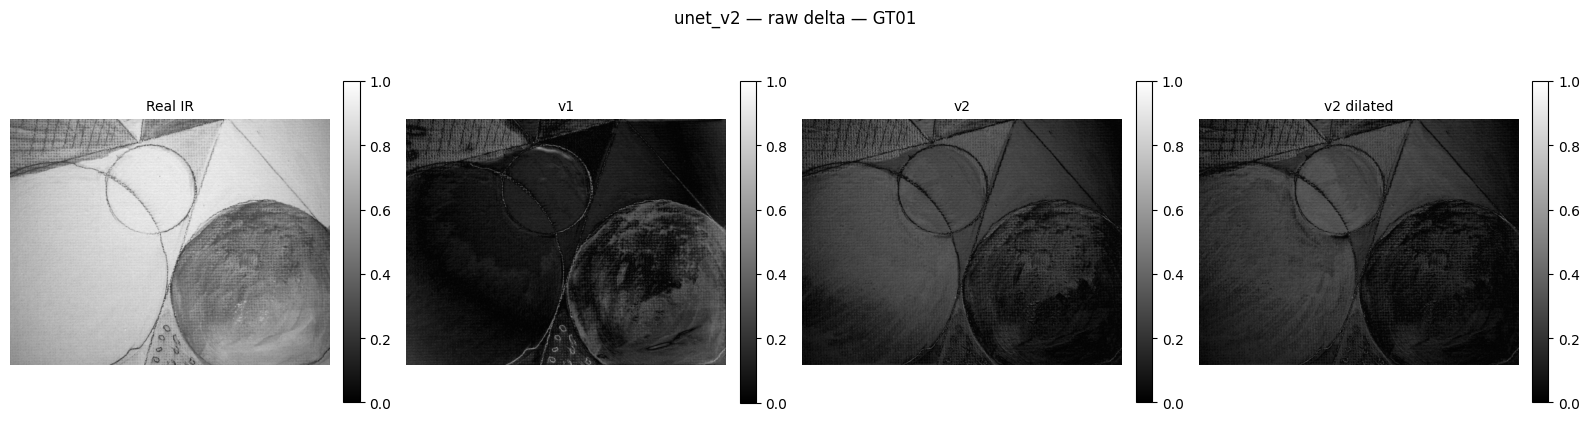

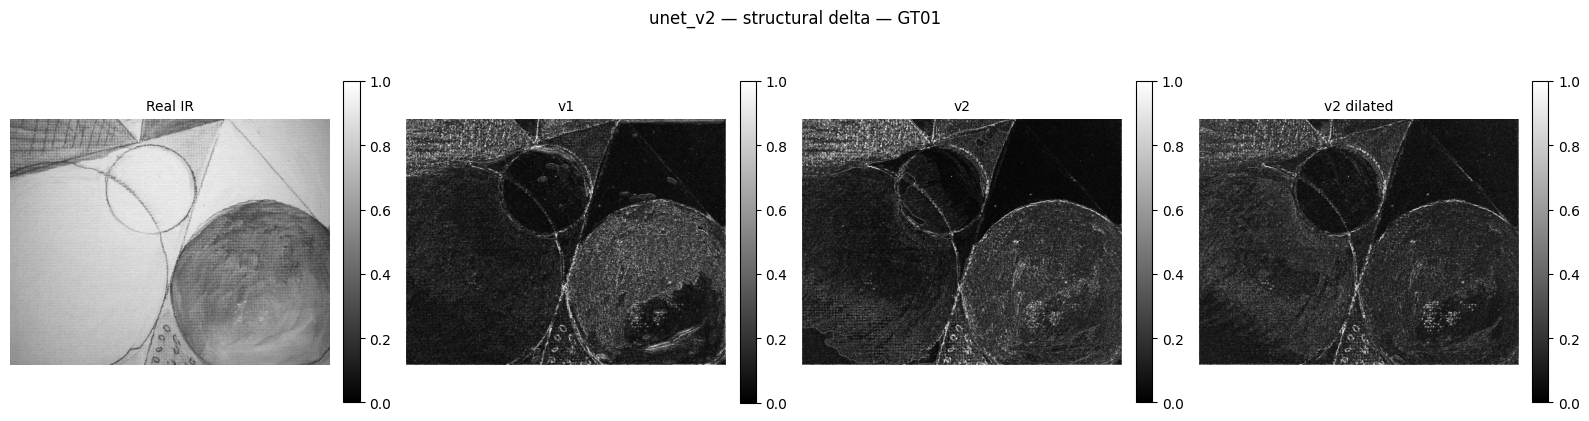

  GT01: scored


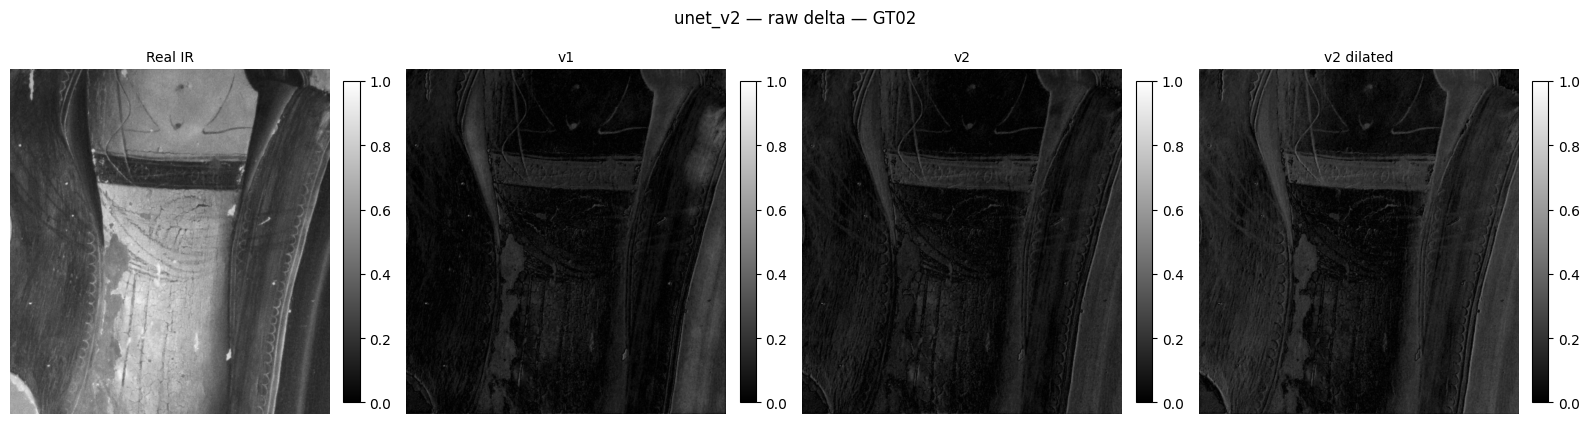

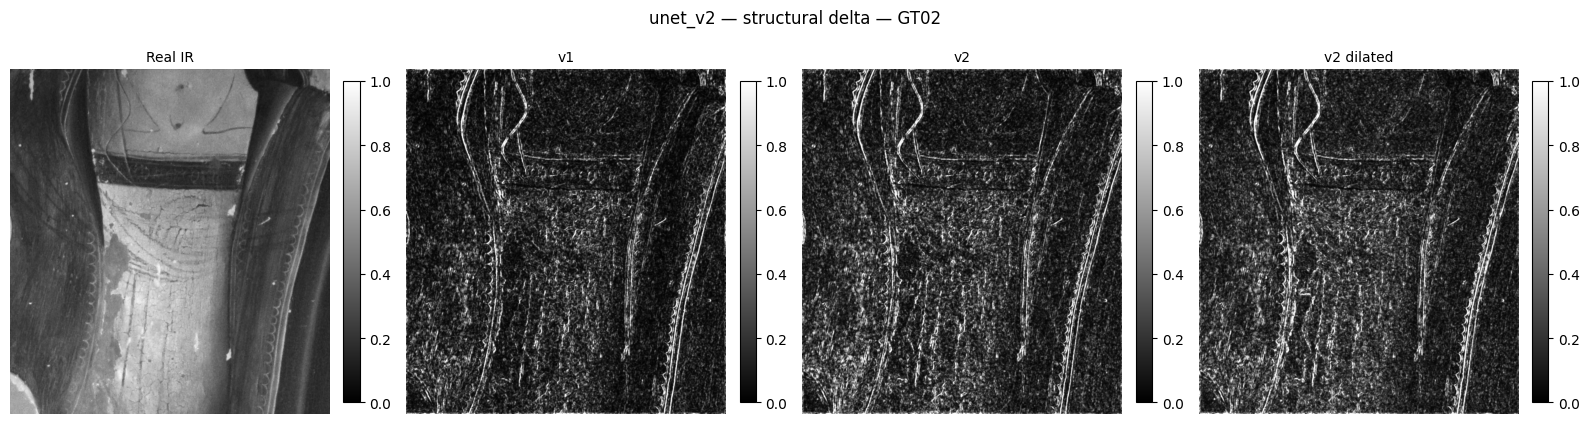

  GT02: scored


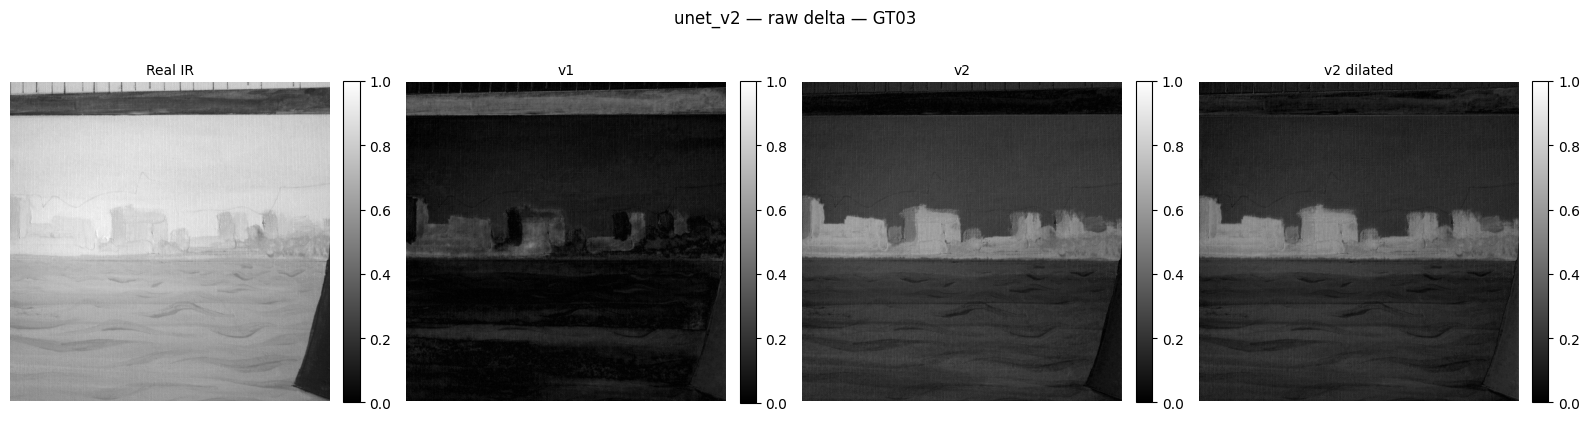

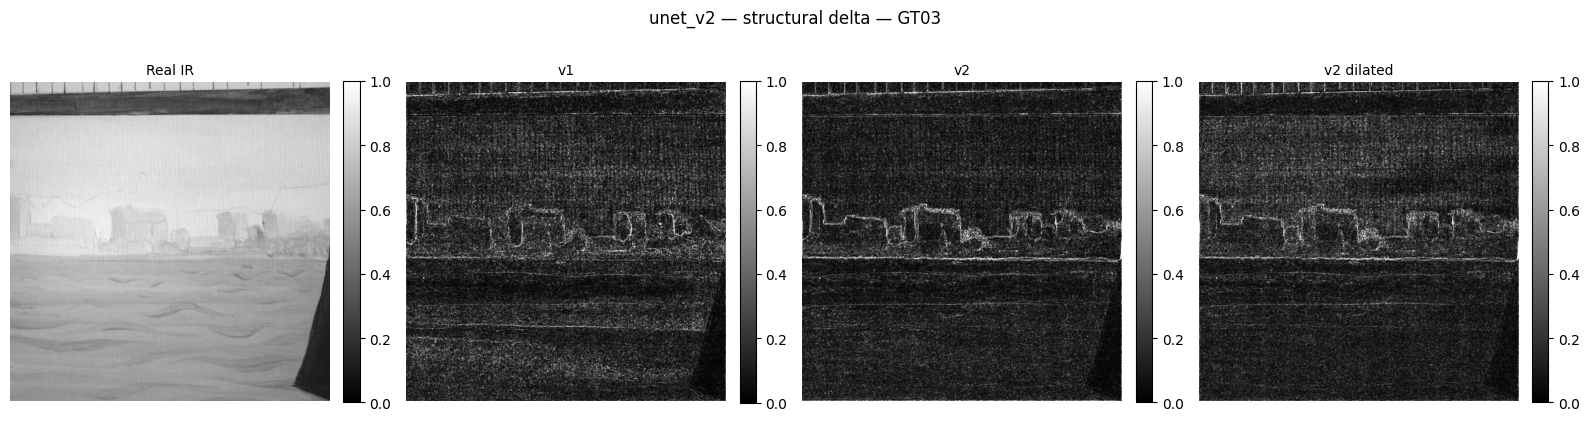

  GT03: scored
  bridge: scored
  case: scored
  face: scored
  green: scored
  modern: scored
  modern2: scored
  total: scored

Compared: ['unet', 'unet_v2']


In [6]:
PLOT_IMAGES = set(gt_stems)  # -> {p.stem for p, _ in image_pairs} for all of them
PLOT_SIGNALS = ("raw delta", "structural delta")

# Keyed by (comparison name, variant label[, signal kind]).
fidelity_rows: dict[tuple[str, str], dict[str, list[float]]] = {}
coherence_rows: dict[tuple[str, str, str], list[float]] = {}
auroc_rows: dict[tuple[str, str, str], dict[str, float]] = {}
ap_rows: dict[tuple[str, str, str], dict[str, float]] = {}
calibration_rows: dict[tuple[str, str], dict[str, list[float]]] = {}

compared: list[Comparison] = []

for comparison in COMPARISONS:
    loaded: dict[str, tf.keras.Model] = {}
    for variant in comparison.variants:
        try:
            loaded[variant.label] = load_variant(variant, comparison.family)
        except FileNotFoundError as exc:
            print(f"[skip] {comparison.name} / {variant.label}: {exc}")

    if len(loaded) < len(comparison.variants):
        print(f"[skip] {comparison.name}: needs every variant's checkpoint to compare")
        del loaded
        gc.collect()
        tf.keras.backend.clear_session()
        continue

    compared.append(comparison)
    print(f"\n=== {comparison.name} ({comparison.family}) — {' vs. '.join(loaded)} ===")

    for rgb_path, ir_path in image_pairs:
        stem = rgb_path.stem
        rgb, ir = load_pair(rgb_path, ir_path)
        mask = load_mask(stem) if stem in gt_stems else None

        per_variant = {}
        for variant in comparison.variants:
            scores, signals, sigma, mu = predict_signals(
                loaded[variant.label], comparison.family, variant.version, rgb, ir
            )
            per_variant[variant.label] = signals
            key = (comparison.name, variant.label)

            for metric, value in scores.items():
                fidelity_rows.setdefault(key, {}).setdefault(metric, []).append(value)

            for kind, signal in signals.items():
                coherence_rows.setdefault((*key, kind), []).append(
                    stroke_coherence(signal).coherence
                )
                if mask is not None:
                    detection = evaluate_detection(signal, mask)
                    auroc_rows.setdefault((*key, kind), {})[stem] = detection.auroc
                    ap_rows.setdefault((*key, kind), {})[stem] = (
                        detection.average_precision
                    )

            if sigma is not None:
                distribution = VERSIONS[variant.version]["sigma_source"]
                summary = evaluate_calibration(
                    ir, mu, sigma, distribution=distribution
                ).summary()
                for metric, value in summary.items():
                    calibration_rows.setdefault(key, {}).setdefault(metric, []).append(
                        value
                    )

        if stem in PLOT_IMAGES:
            n_cols = 1 + len(per_variant)  # + the real-IR panel, all on one row
            for kind in PLOT_SIGNALS:
                fig = plot_signal_comparison(
                    ir,
                    {label: s[kind] for label, s in per_variant.items()},
                    title=f"{comparison.name} — {kind} — {stem}",
                    vrange=(0.0, 1.0),
                    max_cols=n_cols,
                )
                plt.show()
                plt.close(fig)
            if comparison.family == "nll":
                for kind in NLL_SIGNAL_KINDS:
                    scaled, vrange = DEFAULT_Z_SCALE.apply_many(
                        {label: s[kind] for label, s in per_variant.items()}
                    )
                    fig = plot_signal_comparison(
                        ir,
                        scaled,
                        title=f"{comparison.name} — {kind} — {stem}",
                        vrange=vrange,
                        max_cols=n_cols,
                    )
                    plt.show()
                    plt.close(fig)

        print(f"  {stem}: scored")
        del per_variant, rgb, ir, mask

    del loaded
    gc.collect()
    tf.keras.backend.clear_session()

print(f"\nCompared: {[c.name for c in compared]}")
if not compared:
    raise RuntimeError(
        "No comparison had a checkpoint for every variant — nothing to compare."
    )

## 5. Reconstruction fidelity — how well each variant predicts the IR

`mae`/`ssim`/`psnr` of `mu` against the real IR, averaged over all `data/test/` images. This is the same axis `030_evaluation.ipynb` reports, and it measures the *forward* task only: a model can improve here and still surface the underdrawing worse, which is what §6 and §7 are for.

The two `Δ` columns are **consecutive**: `Δ v2-v1` is the fixing rounds' effect, `Δ v2 dilated-v2` is the dilated bottleneck's effect on top of them. Both are oriented so that **positive always means the later variant is better** — `after - before` for `ssim`/`psnr`, `before - after` for `mae`, where lower is better. Read a negative delta as a regression, whatever the metric. To recover the end-to-end v1 → dilated change, add the two.

In [7]:
# True where a *lower* value is the better one, so the deltas below can be
# oriented consistently: positive always means the later variant improved.
LOWER_IS_BETTER = {"mae": True, "ssim": False, "psnr": False}

DELTA_W = 17  # wide enough for the longest "Δ <after>-<before>" header


def mean_of(rows: dict, key, metric: str) -> float:
    return float(np.mean(rows[key][metric]))


def improvement(metric: str, before: float, after: float) -> float:
    """Signed gain of ``after`` over ``before``; positive is always better."""
    return before - after if LOWER_IS_BETTER[metric] else after - before


def table_header(first_col: str, name_w: int, val_w: int) -> str:
    """One column per variant, then one per consecutive step."""
    return (
        first_col.ljust(name_w)
        + "".join(label.rjust(val_w) for label in LABELS)
        + "".join(f"Δ {after}-{before}".rjust(DELTA_W) for before, after in STEPS)
    )


name_w = 30
header = table_header("architecture [metric]", name_w, 12)
print(header)
print("-" * len(header))

for comparison in compared:
    for metric in LOWER_IS_BETTER:
        values = [
            mean_of(fidelity_rows, (comparison.name, label), metric) for label in LABELS
        ]
        row = f"{comparison.name} [{metric}]".ljust(name_w)
        row += "".join(f"{v:.4f}".rjust(12) for v in values)
        row += "".join(
            f"{improvement(metric, before, after):+.4f}".rjust(DELTA_W)
            for before, after in zip(values, values[1:])
        )
        print(row)

print(
    f"\n(mean over {len(image_pairs)} data/test/ images; "
    "Δ > 0 means the later variant is better)"
)

architecture [metric]                   v1          v2  v2 dilated          Δ v2-v1  Δ v2 dilated-v2
----------------------------------------------------------------------------------------------------
unet [mae]                          0.1048      0.1265      0.1341          -0.0217          -0.0075
unet [ssim]                         0.5899      0.6071      0.6029          +0.0172          -0.0042
unet [psnr]                        17.7655     16.6486     16.2389          -1.1169          -0.4097
unet_v2 [mae]                       0.1078      0.1345      0.1296          -0.0268          +0.0049
unet_v2 [ssim]                      0.6231      0.6223      0.6174          -0.0009          -0.0049
unet_v2 [psnr]                     17.5802     16.3156     16.4837          -1.2645          +0.1681

(mean over 10 data/test/ images; Δ > 0 means the later variant is better)


## 6. Detection — the signal that actually matters

AUROC of each signal against the hand-drawn masks, averaged over the ground-truth images only (`GT01`/`GT02`/`GT03`). `0.5` is chance. With `n = 3` the mean hides a lot, so the per-image breakdown follows — read it before treating any delta here as a result.

This is the primary axis of the whole comparison: the project's deliverable is the residual that reveals the underdrawing, not the IR prediction itself. Higher is better for both AUROC and average precision, so both `Δ` columns are plain `after - before`.

In [8]:
def detection_table(
    rows: dict[tuple[str, str, str], dict[str, float]], label: str
) -> None:
    kinds_seen = {kind for _, _, kind in rows}
    ordered_kinds = [k for k in (*SIGNAL_KINDS, *NLL_SIGNAL_KINDS) if k in kinds_seen]
    name_w = 44
    header = table_header("signal", name_w, 12)
    print(header)
    print("-" * len(header))
    for comparison in compared:
        for kind in ordered_kinds:
            keys = [(comparison.name, lbl, kind) for lbl in LABELS]
            if any(key not in rows for key in keys):
                continue
            values = [float(np.mean(list(rows[key].values()))) for key in keys]
            row = f"{comparison.name} [{kind}]".ljust(name_w)
            row += "".join(f"{v:.4f}".rjust(12) for v in values)
            row += "".join(
                f"{after - before:+.4f}".rjust(DELTA_W)
                for before, after in zip(values, values[1:])
            )
            print(row)
    print(f"\n({label}, mean over {sorted(gt_stems)})")


if auroc_rows:
    print("AUROC\n")
    detection_table(auroc_rows, "AUROC")
    print("\n\naverage precision\n")
    detection_table(ap_rows, "average precision")
else:
    print("No ground-truth mask found under data/test/annotations/ — section skipped.")

AUROC

signal                                                v1          v2  v2 dilated          Δ v2-v1  Δ v2 dilated-v2
------------------------------------------------------------------------------------------------------------------
unet [raw delta]                                  0.5763      0.4726      0.4406          -0.1037          -0.0320
unet [structural delta]                           0.6461      0.7073      0.7015          +0.0612          -0.0058
unet [confidence]                                 0.4162      0.5193      0.5527          +0.1031          +0.0333
unet_v2 [raw delta]                               0.6061      0.4198      0.4391          -0.1863          +0.0194
unet_v2 [structural delta]                        0.6762      0.6751      0.6905          -0.0012          +0.0155
unet_v2 [confidence]                              0.4309      0.5691      0.5681          +0.1382          -0.0009

(AUROC, mean over ['GT01', 'GT02', 'GT03'])


average precision

signal 

### Per-image AUROC breakdown

The `n = 3` mean above can be carried entirely by one favourable image. One table per ground-truth image, all three variants side by side, so a delta that only exists on one painting is visible as such.

In [9]:
if auroc_rows:
    name_w = 44
    for stem in sorted(gt_stems):
        header = f"{stem}".ljust(name_w) + "".join(
            label.rjust(12) for label in LABELS
        )
        print(f"\n{header}")
        print("-" * len(header))
        for comparison in compared:
            for kind in (*SIGNAL_KINDS, *NLL_SIGNAL_KINDS):
                keys = [(comparison.name, lbl, kind) for lbl in LABELS]
                if any(key not in auroc_rows for key in keys):
                    continue
                print(
                    f"{comparison.name} [{kind}]".ljust(name_w)
                    + "".join(f"{auroc_rows[key][stem]:.3f}".rjust(12) for key in keys)
                )
else:
    print("No ground-truth mask found — section skipped.")


GT01                                                  v1          v2  v2 dilated
--------------------------------------------------------------------------------
unet [raw delta]                                   0.714       0.442       0.360
unet [structural delta]                            0.688       0.815       0.830
unet [confidence]                                  0.327       0.509       0.530
unet_v2 [raw delta]                                0.716       0.289       0.351
unet_v2 [structural delta]                         0.727       0.727       0.744
unet_v2 [confidence]                               0.324       0.625       0.588

GT02                                                  v1          v2  v2 dilated
--------------------------------------------------------------------------------
unet [raw delta]                                   0.540       0.461       0.496
unet [structural delta]                            0.597       0.662       0.634
unet [confidence]         

## 7. Stroke coherence — the reference-free corroboration

How much of each signal is oriented, line-like structure rather than isotropic noise (`scripts.stroke_stats`). It needs no mask, so unlike §6 it runs on **all** `data/test/` images and is a structurally independent check on the AUROC verdict: a variant that improves detection AUROC on three paintings but degrades coherence across ten is not obviously better.

In [10]:
name_w = 44
header = table_header("signal", name_w, 16)
print(header)
print("-" * len(header))

for comparison in compared:
    for kind in (*SIGNAL_KINDS, *NLL_SIGNAL_KINDS):
        keys = [(comparison.name, lbl, kind) for lbl in LABELS]
        if any(key not in coherence_rows for key in keys):
            continue
        values = [np.array(coherence_rows[key]) for key in keys]
        row = f"{comparison.name} [{kind}]".ljust(name_w)
        row += "".join(f"{v.mean():.3f}±{v.std():.3f}".rjust(16) for v in values)
        row += "".join(
            f"{after.mean() - before.mean():+.4f}".rjust(DELTA_W)
            for before, after in zip(values, values[1:])
        )
        print(row)

print(f"\n(mean ± std over {len(image_pairs)} data/test/ images)")

signal                                                    v1              v2      v2 dilated          Δ v2-v1  Δ v2 dilated-v2
------------------------------------------------------------------------------------------------------------------------------
unet [raw delta]                                 0.251±0.069     0.244±0.069     0.245±0.068          -0.0074          +0.0010
unet [structural delta]                          0.332±0.054     0.357±0.065     0.354±0.063          +0.0247          -0.0030
unet [confidence]                                0.338±0.065     0.338±0.069     0.337±0.069          -0.0008          -0.0005
unet_v2 [raw delta]                              0.254±0.071     0.245±0.067     0.244±0.072          -0.0090          -0.0006
unet_v2 [structural delta]                       0.370±0.074     0.370±0.069     0.360±0.072          -0.0003          -0.0093
unet_v2 [confidence]                             0.365±0.089     0.358±0.079     0.345±0.079          -0.0079  

## 8. Sigma calibration — NLL comparisons only

`mae`/`ssim`/`psnr` and the AUROC of the delta signals all read `mu`; this section scores `sigma` on its own (`scripts.calibration`), averaged over all `data/test/` images — no mask needed, so the full set is used. It only runs for a comparison declared with `family="nll"`; the dilated comparisons configured in §2 are deterministic, so it is skipped as written.

**`nll` is not comparable across a change of distribution**: v1's is a Gaussian NLL, v2's a Laplace NLL, two different densities in nats. The delta is blanked for exactly the steps that cross that boundary (`sigma_source` differs) and kept for steps within one distribution, where the two models really were trained to minimise the same quantity.

The rest are distribution-agnostic and *are* comparable everywhere: `coverage_1s`/`coverage_2s` against nominal `0.6827`/`0.9545`, `z_std` (`1.0` is calibrated, `> 1` overconfident), `ence` (lower is better), `error_sigma_spearman` (higher: sigma tracks where the model is actually wrong), `sharpness` (mean sigma) and `dispersion` (its coefficient of variation — a large *constant* sigma would score well on coverage and be useless, which dispersion catches).

In [11]:
CALIB_KEYS = [
    "nll",
    "ence",
    "z_std",
    "coverage_1s",
    "coverage_2s",
    "error_sigma_spearman",
    "sharpness",
    "dispersion",
]
NOT_COMPARABLE = {"nll"}  # only across a change of distribution — see below


def same_distribution(comparison: Comparison, before: str, after: str) -> bool:
    """True when two variants read sigma from the same density."""
    source = {
        v.label: VERSIONS[v.version]["sigma_source"] for v in comparison.variants
    }
    return source[before] == source[after]


nll_comparisons = [c for c in compared if c.family == "nll"]

if not nll_comparisons:
    print("No NLL comparison in COMPARISONS — section skipped.")
else:
    name_w = 24
    for comparison in nll_comparisons:
        print(f"\n=== {comparison.name} ===")
        header = table_header("metric", name_w, 12)
        print(header)
        print("-" * len(header))
        for metric in CALIB_KEYS:
            values = [
                float(np.mean(calibration_rows[(comparison.name, lbl)][metric]))
                for lbl in LABELS
            ]
            row = metric.ljust(name_w)
            row += "".join(f"{v:.4f}".rjust(12) for v in values)
            for (before, after), (v_before, v_after) in zip(
                STEPS, zip(values, values[1:])
            ):
                blank = metric in NOT_COMPARABLE and not same_distribution(
                    comparison, before, after
                )
                cell = "n/a" if blank else f"{v_after - v_before:+.4f}"
                row += cell.rjust(DELTA_W)
            print(row)
    print("\nnominal coverage: 1s = 0.6827, 2s = 0.9545; calibrated z_std = 1.0")
    print("'n/a' = the two variants' NLLs are in different nats, not subtractable")

No NLL comparison in COMPARISONS — section skipped.


## 9. Verdict — which step bought what

A count, per family and per **step**, of how many measured quantities improved. Deliberately coarse: it collapses three different axes (fidelity, detection, coherence) that do not have to agree, and detection rests on three masks. Use it to see *where the movement is* — the fixing rounds, the dilated bottleneck, or neither — then read §5-§7 for what actually moved.

In [12]:
def tally(gains: list[float]) -> str:
    """``"k/n"`` — how many of these gains are improvements for the later variant."""
    if not gains:
        return "-"
    return f"{sum(g > 0 for g in gains)}/{len(gains)}"


ALL_KINDS = (*SIGNAL_KINDS, *NLL_SIGNAL_KINDS)

name_w = 38
header = (
    "step".ljust(name_w)
    + "fidelity".rjust(12)
    + "detection".rjust(12)
    + "coherence".rjust(12)
)
print(header)
print("-" * len(header))

for comparison in compared:
    for before, after in STEPS:
        fidelity_gains = [
            improvement(
                metric,
                mean_of(fidelity_rows, (comparison.name, before), metric),
                mean_of(fidelity_rows, (comparison.name, after), metric),
            )
            for metric in LOWER_IS_BETTER
        ]
        detection_gains = [
            float(np.mean(list(auroc_rows[(comparison.name, after, kind)].values())))
            - float(np.mean(list(auroc_rows[(comparison.name, before, kind)].values())))
            for kind in ALL_KINDS
            if (comparison.name, before, kind) in auroc_rows
        ]
        coherence_gains = [
            float(np.mean(coherence_rows[(comparison.name, after, kind)]))
            - float(np.mean(coherence_rows[(comparison.name, before, kind)]))
            for kind in ALL_KINDS
            if (comparison.name, before, kind) in coherence_rows
        ]
        print(
            f"{comparison.name}: {after} vs {before}".ljust(name_w)
            + tally(fidelity_gains).rjust(12)
            + tally(detection_gains).rjust(12)
            + tally(coherence_gains).rjust(12)
        )

print("\n(later variant better / total measured; fidelity = mae, ssim, psnr)")

step                                      fidelity   detection   coherence
--------------------------------------------------------------------------
unet: v2 vs v1                                 1/3         2/3         1/3
unet: v2 dilated vs v2                         0/3         1/3         1/3
unet_v2: v2 vs v1                              0/3         1/3         0/3
unet_v2: v2 dilated vs v2                      2/3         2/3         0/3

(later variant better / total measured; fidelity = mae, ssim, psnr)
